# Phase 6 — Positive Drivers & Satisfaction Analysis

Analyzes positive sentiment drivers, high satisfaction products (RSI < 0.3), platform-level satisfaction parity, and extracts primary reasons for customer satisfaction.

In [1]:
# ==============================================================================
# ENVIRONMENT & PATH CONFIGURATION
# Robust path resolution across: Local VS Code / Jupyter / Terminal & Google Colab
# ==============================================================================
import os
import sys

# Mount Google Drive only if running inside Google Colab
try:
    import google.colab
    from google.colab import drive
    drive.mount('/content/drive')
    print("Mounted Google Drive (Google Colab detected).")
except ImportError:
    pass

# Locate project root whether notebook is run from ./notebooks or repo root
CURRENT_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(CURRENT_DIR, '..') if os.path.basename(CURRENT_DIR) == 'notebooks' else CURRENT_DIR)

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

def resolve_path(rel_path):
    """Resolve file path across local workspace, parent directories, or Colab paths."""
    candidates = [
        os.path.join(PROJECT_ROOT, rel_path),
        os.path.join(CURRENT_DIR, rel_path),
        os.path.join(os.path.dirname(PROJECT_ROOT), rel_path),
        os.path.join("/content/drive/MyDrive/DWDM_Project", rel_path),
        os.path.join("/content/Samsung-Regret-Intelligence-System", rel_path),
    ]
    for candidate in candidates:
        if os.path.exists(candidate):
            return os.path.abspath(candidate)
    # Target path for output writes
    target = os.path.join(PROJECT_ROOT, rel_path)
    os.makedirs(os.path.dirname(target), exist_ok=True)
    return os.path.abspath(target)

# Ensure standard output directories exist
for folder in ["data/raw", "data/processed", "data/warehouse", "outputs/plots", "outputs/models", "outputs/tables"]:
    os.makedirs(resolve_path(folder), exist_ok=True)

print(f"Project root resolved: {PROJECT_ROOT}")


Project root resolved: /Users/nithin/Projects/DWDM_Project


## Step 1 — Ingest Processed Dataset & Tag Positive Reviews

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

processed_path = resolve_path("data/processed/samsung_processed_dataset.csv")
df = pd.read_csv(processed_path)

# Reviews with low regret (RSI < 0.3) represent high customer satisfaction
df["Positive"] = (df["RSI"] < 0.3).astype(int)
print("Positive Reviews Distribution:")
print(df["Positive"].value_counts())
df.head()


Positive Reviews Distribution:
Positive
0    4304
1    2932
Name: count, dtype: int64


,Product,Category,Rating,Review,Platform,Date,Sentiment_score,Issue,RSI,Positive
0,Samsung Buds Live,Accessories,5.0,worth it house save decide although bag fight ...,AMAZON,2022-08-17,0.5859,none,0.0600,1
1,Samsung Galaxy M14,Smartphone,2.0,waste of money issue display flickering,FLIPKART,2022-02-21,-0.4215,display,0.6536,0
2,Samsung Galaxy M53,Smartphone,5.0,excellent game threat see head cover task see,amazon,2023-07-18,0.0772,none,0.0600,1
3,Samsung Galaxy Tab A8,Smartphone,4.0,good,AMAZON,2023-05-17,0.4404,none,0.1350,1
4,Samsung Charger 25W,Accessories,1.0,average join hotel daughter water,AMAZON,2023-04-03,0.2960,heating,0.5600,0


## Step 2 — Monthly Satisfaction Trend

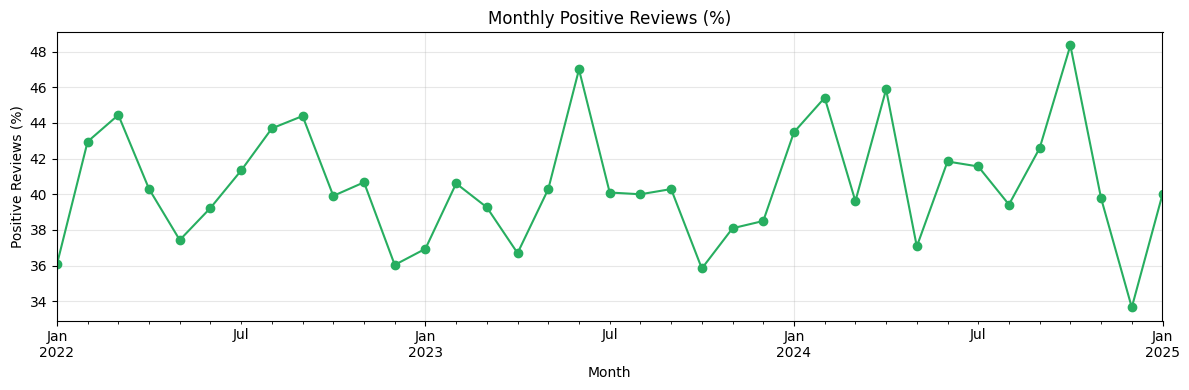

In [3]:
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.to_period("M")

monthly_positive = df.groupby("Month")["Positive"].mean() * 100

fig, ax = plt.subplots(figsize=(12, 4))
monthly_positive.plot(ax=ax, title="Monthly Positive Reviews (%)", marker='o', color='#27ae60')
ax.set_ylabel("Positive Reviews (%)")
ax.grid(alpha=0.3)
plt.tight_layout()

sat_plot_path = resolve_path("outputs/plots/monthly_satisfaction_trend.png")
plt.savefig(sat_plot_path, dpi=150, bbox_inches='tight')
plt.show()


## Step 3 — Top 10 Satisfied Products

Product
Samsung Soundbar           0.575758
Samsung Refrigerator       0.575758
Samsung Galaxy Z Fold5     0.542857
Samsung QLED TV            0.529412
Samsung Air Conditioner    0.517241
Samsung Galaxy Buds2       0.500000
Samsung Galaxy Watch6      0.472222
Samsung Washing Machine    0.444444
Samsung Galaxy M53         0.423163
Samsung Galaxy S23         0.420323
Name: Positive, dtype: float64


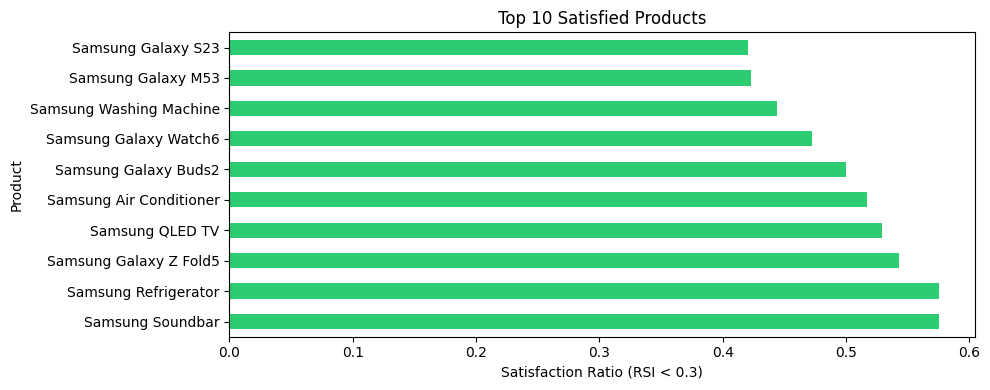

In [4]:
top_positive_products = df.groupby("Product")["Positive"].mean().sort_values(ascending=False).head(10)
print(top_positive_products)

fig, ax = plt.subplots(figsize=(10, 4))
top_positive_products.plot(kind="barh", ax=ax, color='#2ecc71', title="Top 10 Satisfied Products")
ax.set_xlabel("Satisfaction Ratio (RSI < 0.3)")
plt.tight_layout()

top_sat_path = resolve_path("outputs/plots/top_satisfied_products.png")
plt.savefig(top_sat_path, dpi=150, bbox_inches='tight')
plt.show()


## Step 4 — Platform & Category Satisfaction Parity

In [5]:
platform_positive = df.groupby("Platform")["Positive"].mean() * 100
print("Platform Satisfaction (%):\n", platform_positive)

category_positive = df.groupby("Category")["Positive"].mean().sort_values(ascending=False)
print("\nCategory Satisfaction (%):\n", category_positive)


Platform Satisfaction (%):
 Platform
AMAZON      40.767123
FLIPKART    40.578919
amazon      40.262582
flipkart    40.468037
Name: Positive, dtype: float64

Category Satisfaction (%):
 Category
Other          0.526718
TV             0.455882
Accessories    0.402837
Smartphone     0.402346
Name: Positive, dtype: float64


## Step 5 — Positive Reason Extraction

Satisfaction Reasons:
Positive_Reason
overall_good        1195
general_positive     997
value_for_money      648
build_quality         57
performance           35
Name: count, dtype: int64


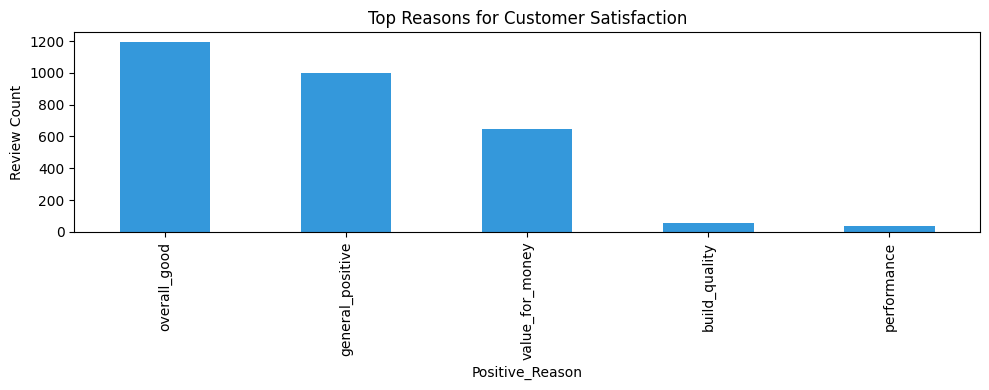

In [6]:
positive_reviews = df[df["Positive"] == 1].copy()

def extract_positive_reason(text):
    text = str(text).lower()

    reason_map = {
        "performance": ["fast", "smooth", "speed", "lag free", "quick"],
        "battery": ["battery good", "long battery", "backup", "lasting"],
        "camera": ["camera good", "clear photo", "quality photo"],
        "display": ["display good", "bright", "clear screen"],
        "value_for_money": ["worth", "value", "price", "budget", "cheap"],
        "build_quality": ["premium", "strong", "design", "look", "finish"],
        "sound": ["sound good", "audio clear", "loud"],
        "overall_good": ["good", "excellent", "best", "awesome", "perfect"]
    }

    scores = {}
    for reason, keywords in reason_map.items():
        score = sum(word in text for word in keywords)
        if score > 0:
            scores[reason] = score

    if scores:
        return max(scores, key=scores.get)
    return "general_positive"

positive_reviews["Positive_Reason"] = positive_reviews["Review"].apply(extract_positive_reason)
reason_counts = positive_reviews["Positive_Reason"].value_counts()
print("Satisfaction Reasons:")
print(reason_counts)

fig, ax = plt.subplots(figsize=(10, 4))
reason_counts.head(8).plot(kind="bar", ax=ax, title="Top Reasons for Customer Satisfaction", color='#3498db')
ax.set_ylabel("Review Count")
plt.tight_layout()

reasons_plot_path = resolve_path("outputs/plots/top_satisfaction_reasons.png")
plt.savefig(reasons_plot_path, dpi=150, bbox_inches='tight')
plt.show()


## Step 6 — Export Top Positive Products

In [7]:
out_top_pos = resolve_path("outputs/top_positive_products.csv")
top_positive_products.to_csv(out_top_pos)
print(f"✅ Exported top positive products to {out_top_pos}")


✅ Exported top positive products to /Users/nithin/Projects/DWDM_Project/outputs/top_positive_products.csv
